# Reversible SU(3) field-transform downsampling: L24 → L12

The L24 and L12 ensembles are Wilson pure-gauge SU(3) configurations with 300 saved configurations each. Fine L24 links first pass through a gauge-equivariant, reversible field transform and are then factor-two blocked. The transform is reversible; the dimensional reduction from blocking is not.

This notebook compares the transformed and naively blocked ensembles to the native L12 reference. Its default is a short full held-out test: three training configurations and one validation configuration for one epoch, evaluated on the complete 60-configuration test split from the standard 180/60/60 partition. The plots therefore show all held-out test configurations, while the short optimization budget means this is a speed-limited diagnostic rather than a production-quality fit. Set `RGFLOW_DOWNSAMPLE_RUN` to inspect another completed run.

In [1]:
from pathlib import Path
import csv, json, os, sys
import numpy as np
import matplotlib.pyplot as plt

ROOT = next(path for path in (Path.cwd(), Path.cwd().parent) if (path / 'artifacts').exists())
# Default to the short run evaluated on the complete held-out test split.
RUN = Path(os.environ.get('RGFLOW_DOWNSAMPLE_RUN', ROOT / 'artifacts' / '4dsu3' / 'downsample' / 'L24_beta6p20_to_L12_beta5p80_field_transform_v4_full_test_1epoch'))
required = ('history.csv', 'metrics.json', 'kernel.json', 'observable_distributions.npz')
missing = [filename for filename in required if not (RUN / filename).exists()]
completed = not missing
history = None
if (RUN / 'history.csv').exists():
    with (RUN / 'history.csv').open(newline='', encoding='utf-8') as stream:
        rows = list(csv.DictReader(stream))
    history = {key: np.asarray([float(row[key]) for row in rows]) for key in rows[0]}
if completed:
    metrics = json.loads((RUN / 'metrics.json').read_text(encoding='utf-8'))
    kernel = json.loads((RUN / 'kernel.json').read_text(encoding='utf-8'))
    saved = np.load(RUN / 'observable_distributions.npz')
    names = tuple(metrics['observables'])
    if kernel.get('final_evaluation_splits') == ['test']:
        reference = saved['reference_test']
        baseline = saved['baseline_test']
        downsampled = saved['trained_test']
        distribution_scope = 'held-out test split'
    else:
        reference = saved['reference_all']
        baseline = np.empty_like(reference)
        downsampled = np.empty_like(reference)
        for split, indices in kernel['data_split'].items():
            baseline[np.asarray(indices)] = saved[f'baseline_{split}']
            downsampled[np.asarray(indices)] = saved[f'trained_{split}']
        distribution_scope = 'all configurations'
sys.path.insert(0, str(ROOT / 'scripts' / 'heatbath'))
from plot_settings import (
    BLUE, FIG_SIZE, FONT_SIZE, GREEN, LABEL_SIZE, LEGEND_SIZE, ORANGE, apply_plot_style, default_plot,
)
apply_plot_style()
plt.rcParams.update({
    'axes.labelsize': FONT_SIZE['fontsize'],
    'axes.titlesize': FONT_SIZE['fontsize'],
    'legend.fontsize': LEGEND_SIZE['fontsize'],
    'axes.formatter.use_mathtext': True,
})

def style_axis(axis):
    axis.tick_params(direction='in', top=True, right=True, **LABEL_SIZE)
    axis.grid(linestyle=':')

if completed:
    test = metrics['splits']['test']['trained']['loss']
    old = metrics['acceptance']['reference_cnn_test_loss']
    print(f'{RUN.name}: {distribution_scope}, {len(reference)} configurations, best epoch {metrics["best_epoch"]}, test loss {test:.6g}, prior CNN {old:.6g}')
else:
    print(f'{RUN.name}: training is in progress; final artifacts are not available yet (missing {", ".join(missing)}).')

L24_beta6p20_to_L12_beta5p80_field_transform_v4_full_test_1epoch: held-out test split, 60 configurations, best epoch 1, test loss 1.16866e+07, prior CNN 202974


## Training loss

The production protocol uses a rotating subset of 30 training configurations and a fixed 12-configuration validation set. The default speed-limited run instead uses three training configurations, one validation configuration, and one epoch, then evaluates the selected checkpoint on every configuration in the held-out 60-configuration test split.

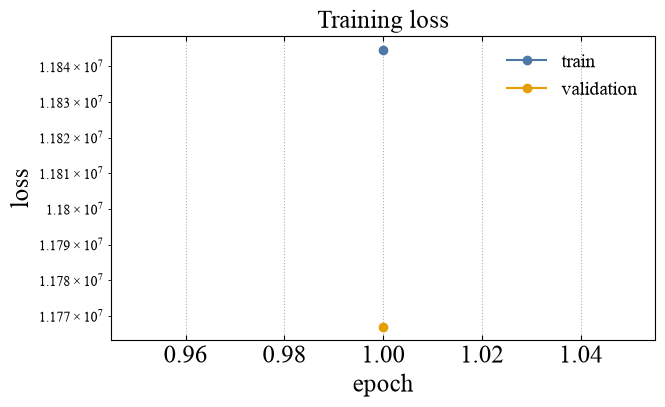

In [2]:
if history is None:
    print('Training has not produced an epoch yet; rerun this cell after the first epoch.')
else:
    figure, axis = default_plot()
    axis.plot(history['epoch'], history['train_loss'], 'o-', color=BLUE, label='train')
    axis.plot(history['epoch'], history['validation_loss'], 'o-', color=ORANGE, label='validation')
    axis.set_xlabel('epoch')
    axis.set_ylabel('loss')
    axis.set_title('Training loss')
    axis.set_yscale('log')
    axis.legend(frameon=False)
    figure.tight_layout()
    plt.show()

## Observable distributions

The four observables use shared Freedman–Diaconis bins across the native L12, reversible-field-transform, and naive-blocking samples.

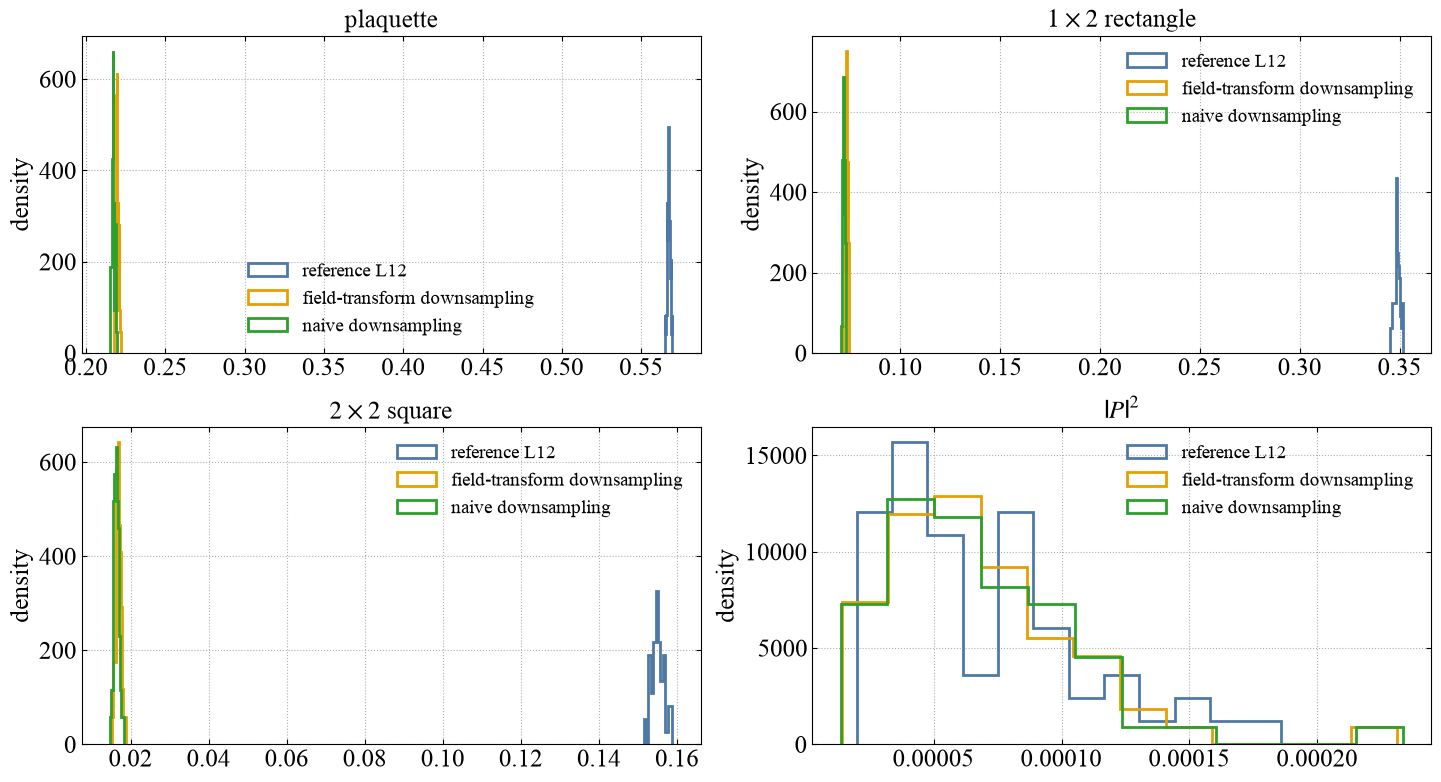

In [3]:
def sample_bins(values, minimum=12, maximum=40):
    values = np.asarray(values, dtype=float)
    lower, upper = float(values.min()), float(values.max())
    if upper <= lower:
        pad = 0.5 if upper == lower else 0.05 * max(abs(lower), 1.0)
        return np.linspace(lower - pad, upper + pad, minimum + 1)
    iqr = float(np.percentile(values, 75) - np.percentile(values, 25))
    width = 2.0 * iqr * len(values) ** (-1.0 / 3.0)
    count = minimum if width <= 0 else int(np.ceil((upper - lower) / width))
    count = int(np.clip(count, minimum, maximum))
    return np.linspace(lower, upper, count + 1)

if completed:
    labels = {
        'plaquette': 'plaquette',
        'rectangle_1x2': r'$1\times 2$ rectangle',
        'square_2x2': r'$2\times 2$ square',
        'polyakov_abs2': r'$|P|^2$',
    }
    series = (
        (reference, BLUE, 'reference L12'),
        (downsampled, ORANGE, 'field-transform downsampling'),
        (baseline, GREEN, 'naive downsampling'),
    )
    figure, axes = plt.subplots(2, 2, figsize=(FIG_SIZE[0] * 2.15, FIG_SIZE[1] * 1.9))
    for index, (axis, name) in enumerate(zip(axes.flat, names)):
        for sample, color, label in series:
            values = sample[:, index]
            axis.hist(values, bins=sample_bins(values), density=True, histtype='step', linewidth=2.0, color=color, label=label)
        style_axis(axis)
        axis.set_title(labels.get(name, name))
        axis.set_ylabel('density')
        axis.legend(frameon=False)
    figure.tight_layout()
    plt.show()
else:
    print('Observable distributions are written after final checkpoint evaluation.')

## Reversible gauge-equivariant field transform

For directions $\mu=0,1,2,3$, the transform updates every fine link with

$$U'_\mu(x)=\exp[Q_\mu(x)]U_\mu(x).$$

Each direction is split into the 16 $2^4$ site parities. For an active $U_\mu(x)$, $Q_\mu(x)\in\mathfrak{su}(3)$ is a bounded combination of twelve transported $\mu$--$\nu$ plaquettes based at $x\pm\hat\rho$, with $\rho\ne\nu$. These loops contain only inactive $\mu$ links. Their twelve complex traces live on the active parity sublattice, where a three-layer periodic $3\times3\times3\times3$ CNN maps 24 real channels to 12 real coefficients. Thus every coupling update is independent of its active links while using a wider neighboring gauge-invariant context. The exact inverse reverses direction and parity order and uses $\exp[-Q_\mu(x)]$. Each layer is a context-dependent left multiplication on SU(3), so it preserves the product Haar measure. Finally, ordinary two-link factor-two blocking is applied; that final reduction is intentionally lossy.